In [2]:
import pandas as pd
from pathlib import Path
# Repository root from /notebooks
PROJECT_ROOT = Path.cwd().parent
# Corrección de la carpeta de outputs (es 'outputs', no 'out')
OUTPUTS_ROOT = PROJECT_ROOT / "outputs"

# Ruta exacta hasta el archivo de entrenamiento (train)
ngboost_regressor = (
        OUTPUTS_ROOT / "runs" / "regression" / "phm2024" / "20260604_191707"
        / "phase4_data_modeling" / "4.2.training.ngboost_regressor.pkl"
)

print("¿El archivo Parquet existe?:", ngboost_regressor.exists())
print("Ruta completa:", ngboost_regressor)

¿El archivo Parquet existe?: True
Ruta completa: K:\00_Code\Manutenzione\Project_MPPR-AI_B_PHM_America_2024\outputs\runs\regression\phm2024\20260604_191707\phase4_data_modeling\4.2.training.ngboost_regressor.pkl


Modelo cargado exitosamente: <class 'ngboost.api.NGBRegressor'>
Variables esperadas por el modelo (importances): 19
Nombres proporcionados (feature_names): 6

⚠️ ERROR: Hay un desajuste. Generando nombres genéricos temporales para poder graficar...


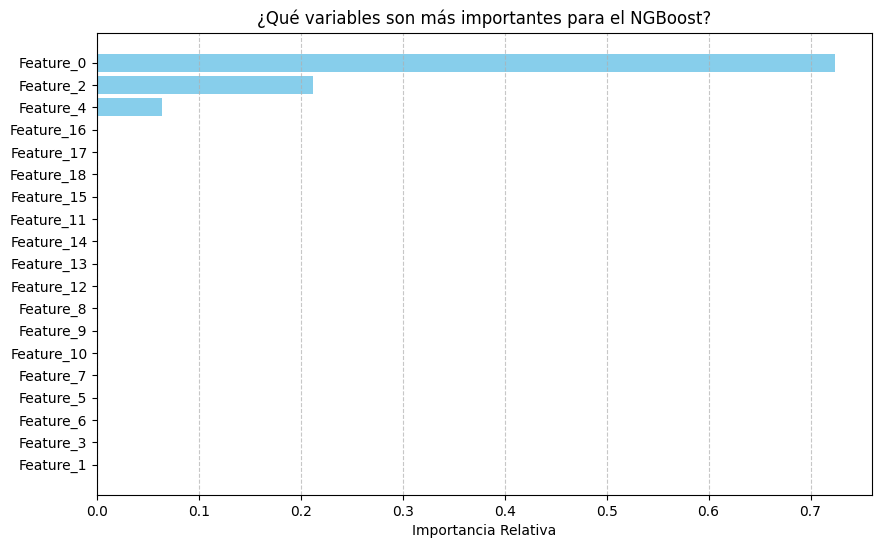

In [5]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib

# 1. Cargar el modelo
model = joblib.load(ngboost_regressor)
print("Modelo cargado exitosamente:", type(model))

# 2. Extraer la importancia de las características
importances = model.feature_importances_[0]

# Tus nombres actuales (6 elementos)
feature_names = ['np^2', 'mgt np', 'trq_measured np', 'mgt^2', 'mgt trq_measured', 'pa']

# --- NUEVO: Comprobación de seguridad ---
print(f"Variables esperadas por el modelo (importances): {len(importances)}")
print(f"Nombres proporcionados (feature_names): {len(feature_names)}")

if len(feature_names) != len(importances):
    print("\n⚠️ ERROR: Hay un desajuste. Generando nombres genéricos temporales para poder graficar...")
    # Genera nombres como 'Feature_0', 'Feature_1', etc., para evitar que el código se rompa
    feature_names = [f"Feature_{i}" for i in range(len(importances))]

# 3. Crear un DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# 4. Graficar
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importancia Relativa')
plt.title('¿Qué variables son más importantes para el NGBoost?')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

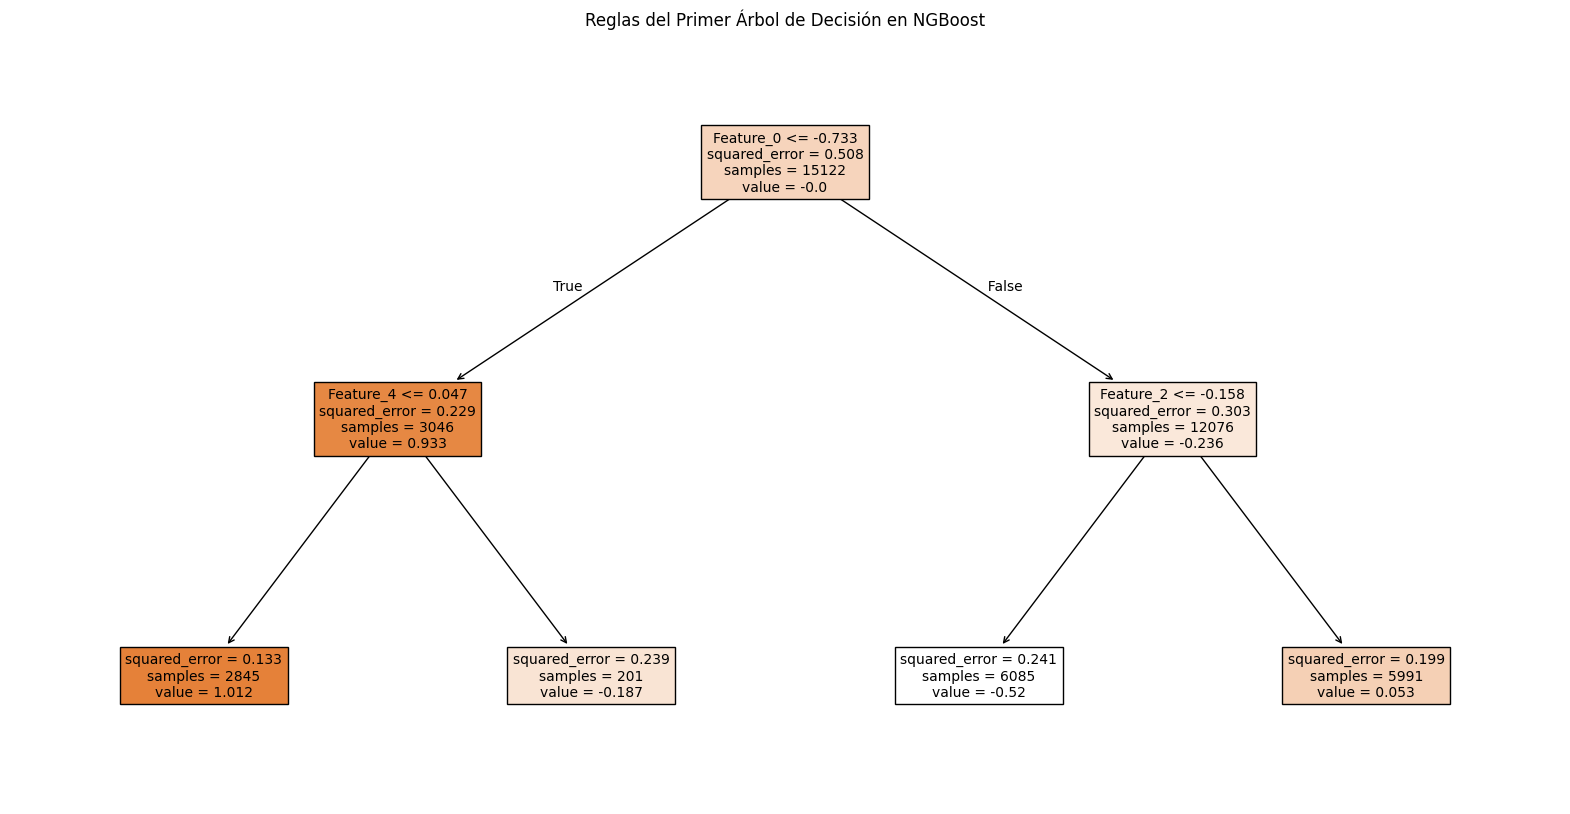

In [6]:
from sklearn.tree import plot_tree

# Extraer el primer árbol de decisión que entrena la media (mu)
primer_arbol = model.base_models[0][0]

plt.figure(figsize=(20, 10))
plot_tree(
    primer_arbol,
    filled=True,
    feature_names=feature_names,
    max_depth=3, # Limitamos la profundidad para que no se vea como una mancha ilegible
    fontsize=10
)
plt.title("Reglas del Primer Árbol de Decisión en NGBoost")
plt.show()

In [7]:
import pandas as pd

# Usamos la ruta del parquet de entrenamiento del paso 3.5 que sale en tu YAML
ruta_parquet_train = "K:/00_Code/Manutenzione/Project_MPPR-AI_B_PHM_America_2024/outputs/runs/regression/phm2024/20260604_191546/phase3_data_preparation/3.5.formatting.regression_internal_train.parquet"

df_train = pd.read_parquet(ruta_parquet_train)

# Quitamos el target si está en el parquet para ver solo los features
columnas_modelo = [col for col in df_train.columns if col != 'trq_margin']

print("Nombres reales de las 19 variables en orden:\n")
for i, nombre in enumerate(columnas_modelo):
    print(f"Feature_{i}: {nombre}")

Nombres reales de las 19 variables en orden:

Feature_0: oat
Feature_1: mgt
Feature_2: pa
Feature_3: ias
Feature_4: np
Feature_5: ng
Feature_6: trq_measured
Feature_7: mgt_oat_ratio
Feature_8: specific_power_index
Feature_9: mgt^2
Feature_10: mgt ng
Feature_11: mgt trq_measured
Feature_12: mgt np
Feature_13: ng^2
Feature_14: ng trq_measured
Feature_15: ng np
Feature_16: trq_measured^2
Feature_17: trq_measured np
Feature_18: np^2


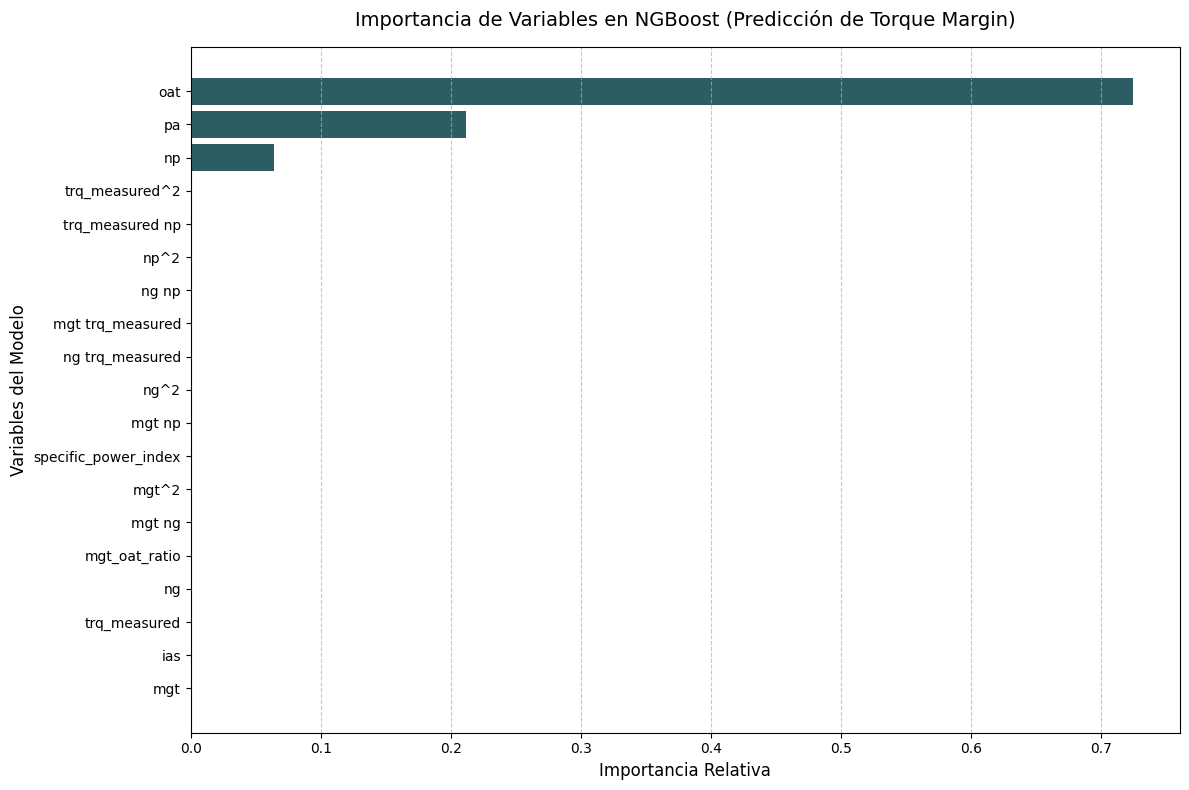

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# 1. Cargar el modelo (asegúrate de que ngboost_regressor esté definido en una celda anterior)
model = joblib.load(ngboost_regressor)

# 2. Extraer la importancia de las características
importances = model.feature_importances_[0]

# 3. La lista exacta y ordenada de variables según tu pipeline
feature_names = [
    'oat', 'mgt', 'pa', 'ias', 'np', 'ng', 'trq_measured',
    'mgt_oat_ratio', 'specific_power_index', 'mgt^2', 'mgt ng',
    'mgt trq_measured', 'mgt np', 'ng^2', 'ng trq_measured',
    'ng np', 'trq_measured^2', 'trq_measured np', 'np^2'
]

# 4. Crear el DataFrame para organizar los datos
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# 5. Graficar con estilo profesional
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#2c5d63')
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variables del Modelo', fontsize=12)
plt.title('Importancia de Variables en NGBoost (Predicción de Torque Margin)', fontsize=14, pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Opcional: Ajustar los márgenes para que los nombres largos se lean bien
plt.tight_layout()
plt.show()